# 08 — COVID-19 Forecasting: Random Forest + SARIMA

## Objective

Redo the COVID-19 forecasting stage using two complementary forecasting approaches:

1. **Random Forest Regression** using lag and rolling-window features.
2. **SARIMA** (Seasonal ARIMA) for the national COVID-19 time series.

The notebook uses **dual-mode validation**:

- **Mode A — Historical holdout:** the final portion of the historical series is held out as an untouched test set.
- **Mode B — Rolling-origin / time-series validation:** multiple chronological validation windows are evaluated without random shuffling.

The final output is saved as:

`forecast_results.csv`

> The source dataset must be the cleaned `covid_clean.csv` produced earlier in the project.


In [3]:
#%pip install statsmodels

In [4]:
# 1. Imports and configuration

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams["figure.figsize"] = (13, 6)

DATA_PATH = Path("C:\\Users\\admin\\Desktop\\covid-19\\data\\processed\\covid_clean.csv")
OUTPUT_PATH = Path("forecast_results.csv")

FORECAST_HORIZON = 30

print("Data file:", DATA_PATH.resolve())
print("Forecast horizon:", FORECAST_HORIZON, "days")


Data file: C:\Users\admin\Desktop\covid-19\data\processed\covid_clean.csv
Forecast horizon: 30 days


In [5]:
# 2. Load and validate cleaned COVID data

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "covid_clean.csv was not found. Put the cleaned COVID CSV in the same "
        "folder as this notebook before running it."
    )

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

required = {"Date", "State/UnionTerritory"}
if not required.issubset(df.columns):
    raise ValueError(f"Dataset must contain at least: {required}")

# Prefer the cleaned daily case field if available.
if "NewCases" not in df.columns:
    if "Confirmed" not in df.columns:
        raise ValueError("Dataset needs either NewCases or Confirmed.")
    df = df.sort_values(["State/UnionTerritory", "Date"])
    df["NewCases"] = df.groupby("State/UnionTerritory")["Confirmed"].diff()

df["NewCases"] = pd.to_numeric(df["NewCases"], errors="coerce")
df = df.dropna(subset=["Date", "NewCases"])

print("Shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("States:", df["State/UnionTerritory"].nunique())


Shape: (18064, 10)
Date range: 2020-01-31 00:00:00 to 2021-08-11 00:00:00
States: 41


In [6]:
# 3. National daily series

# State-level NewCases are summed to create the national daily series.
# Negative revisions are retained for auditability but clipped at zero for
# the forecasting target because the model predicts daily reported cases.

national = (
    df.groupby("Date", as_index=False)["NewCases"]
      .sum()
      .sort_values("Date")
)

national["NewCases"] = national["NewCases"].clip(lower=0)

# Fill missing calendar dates with zero only after aggregation.
full_dates = pd.date_range(
    national["Date"].min(),
    national["Date"].max(),
    freq="D"
)

national = (
    national.set_index("Date")
            .reindex(full_dates)
            .rename_axis("Date")
            .reset_index()
)

national["NewCases"] = national["NewCases"].fillna(0)

# Smooth the noisy reporting series.
national["Cases_7d"] = national["NewCases"].rolling(
    7, min_periods=1
).mean()

print(national.head())
print("\nNational observations:", len(national))


        Date  NewCases  Cases_7d
0 2020-01-31       0.0  0.000000
1 2020-02-01       1.0  0.500000
2 2020-02-02       1.0  0.666667
3 2020-02-03       0.0  0.500000
4 2020-02-04       0.0  0.400000

National observations: 559


In [7]:
# 4. Final historical holdout

# Chronological split: last 20% is test data.
split_idx = int(len(national) * 0.80)

train = national.iloc[:split_idx].copy()
test = national.iloc[split_idx:].copy()

print("Training:", train["Date"].min(), "to", train["Date"].max())
print("Testing :", test["Date"].min(), "to", test["Date"].max())
print("Train size:", len(train))
print("Test size :", len(test))


Training: 2020-01-31 00:00:00 to 2021-04-21 00:00:00
Testing : 2021-04-22 00:00:00 to 2021-08-11 00:00:00
Train size: 447
Test size : 112


In [8]:
# 5. Evaluation metrics

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    nonzero = y_true != 0
    if nonzero.any():
        mape = np.mean(
            np.abs((y_true[nonzero] - y_pred[nonzero]) /
                   y_true[nonzero])
        ) * 100
    else:
        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }


## 6. Mode A — Historical Holdout

The final 20% of the historical data is kept completely out of model fitting.

This gives a realistic answer to:

> How well would the model have forecast the later part of the observed pandemic period using only earlier information?


In [9]:
# 7. Random Forest feature engineering

def make_features(series_df):
    out = series_df[["Date", "NewCases"]].copy()

    # Lag features
    for lag in [1, 2, 3, 7, 14, 21, 28]:
        out[f"lag_{lag}"] = out["NewCases"].shift(lag)

    # Rolling statistics use only past observations.
    out["rolling_mean_7"] = out["NewCases"].shift(1).rolling(7).mean()
    out["rolling_mean_14"] = out["NewCases"].shift(1).rolling(14).mean()
    out["rolling_mean_28"] = out["NewCases"].shift(1).rolling(28).mean()

    out["rolling_std_7"] = out["NewCases"].shift(1).rolling(7).std()
    out["rolling_std_14"] = out["NewCases"].shift(1).rolling(14).std()

    out["day_of_week"] = out["Date"].dt.dayofweek
    out["day_of_month"] = out["Date"].dt.day
    out["month"] = out["Date"].dt.month

    return out.dropna().reset_index(drop=True)

rf_data = make_features(national)

features = [c for c in rf_data.columns if c not in ["Date", "NewCases"]]

rf_train = rf_data[rf_data["Date"] <= train["Date"].max()].copy()
rf_test = rf_data[rf_data["Date"] > train["Date"].max()].copy()

X_train = rf_train[features]
y_train = rf_train["NewCases"]

X_test = rf_test[features]
y_test = rf_test["NewCases"]

print("RF train:", X_train.shape)
print("RF test :", X_test.shape)


RF train: (419, 15)
RF test : (112, 15)


In [10]:
# 8. Random Forest — historical holdout

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=14,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_test_pred = np.maximum(rf.predict(X_test), 0)

rf_holdout_metrics = metrics(y_test, rf_test_pred)

print("Random Forest holdout metrics:")
print(rf_holdout_metrics)

rf_importance = (
    pd.Series(rf.feature_importances_, index=features)
      .sort_values(ascending=False)
)

display(rf_importance.to_frame("Importance"))


Random Forest holdout metrics:
{'MAE': 41864.09573908536, 'RMSE': np.float64(64203.46355112211), 'MAPE (%)': np.float64(24.286128566844756)}


,Importance
lag_1,0.549903
rolling_mean_7,0.129175
rolling_std_14,0.089596
lag_3,0.085734
lag_2,0.071456
rolling_mean_14,0.020573
rolling_std_7,0.018165
lag_7,0.010429
lag_14,0.010094
rolling_mean_28,0.004267


In [11]:
# 9. SARIMA — historical holdout

sarima_train = train.set_index("Date")["NewCases"].asfreq("D").fillna(0)
sarima_test = test.set_index("Date")["NewCases"].asfreq("D").fillna(0)

# Weekly reporting seasonality is represented with seasonal period 7.
# A compact order is used to keep the model practical.
sarima_model = SARIMAX(
    sarima_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

sarima_test_forecast = sarima_fit.forecast(steps=len(sarima_test))
sarima_test_forecast = np.maximum(
    np.asarray(sarima_test_forecast),
    0
)

sarima_holdout_metrics = metrics(
    sarima_test.values,
    sarima_test_forecast
)

print("SARIMA holdout metrics:")
print(sarima_holdout_metrics)


SARIMA holdout metrics:
{'MAE': 832440.8978071327, 'RMSE': np.float64(979125.5511558958), 'MAPE (%)': np.float64(1723.7731670423943)}


In [12]:
# 10. Holdout model comparison

holdout_comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        **rf_holdout_metrics
    },
    {
        "Model": "SARIMA",
        **sarima_holdout_metrics
    }
]).sort_values("RMSE")

display(holdout_comparison)


,Model,MAE,RMSE,MAPE (%)
0,Random Forest,41864.095739,64203.463551,24.286129
1,SARIMA,832440.897807,979125.551156,1723.773167


## 11. Mode B — Rolling-Origin Validation

Rolling-origin validation evaluates the models at multiple historical forecast origins.

No future observations are used to predict an earlier validation window.

For computational efficiency, the validation uses several 14-day windows. The same procedure can be expanded to more folds if required.


In [13]:
# 12. Rolling-origin validation helpers

def rf_recursive_forecast(train_df, horizon):
    history = train_df[["Date", "NewCases"]].copy().reset_index(drop=True)

    model_data = make_features(history)
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    model.fit(model_data[features], model_data["NewCases"])

    predictions = []

    for _ in range(horizon):
        temp = history.copy()

        row = {
            "Date": temp["Date"].iloc[-1] + pd.Timedelta(days=1),
            "NewCases": np.nan
        }
        temp = pd.concat(
            [temp, pd.DataFrame([row])],
            ignore_index=True
        )

        # Build features using only the available historical values.
        feature_row = pd.DataFrame({"Date": [temp["Date"].iloc[-1]]})

        values = history["NewCases"].tolist()

        for lag in [1, 2, 3, 7, 14, 21, 28]:
            feature_row[f"lag_{lag}"] = values[-lag]

        for window in [7, 14, 28]:
            feature_row[f"rolling_mean_{window}"] = np.mean(values[-window:])

        feature_row["rolling_std_7"] = (
            np.std(values[-7:], ddof=1) if len(values[-7:]) > 1 else 0
        )
        feature_row["rolling_std_14"] = (
            np.std(values[-14:], ddof=1) if len(values[-14:]) > 1 else 0
        )

        date = feature_row["Date"].iloc[0]
        feature_row["day_of_week"] = date.dayofweek
        feature_row["day_of_month"] = date.day
        feature_row["month"] = date.month

        pred = float(max(model.predict(feature_row[features])[0], 0))
        predictions.append(pred)

        history = pd.concat(
            [
                history,
                pd.DataFrame([{
                    "Date": date,
                    "NewCases": pred
                }])
            ],
            ignore_index=True
        )

    return np.array(predictions)


def sarima_forecast(train_df, horizon):
    series = (
        train_df.set_index("Date")["NewCases"]
        .asfreq("D")
        .fillna(0)
    )

    model = SARIMAX(
        series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    return np.maximum(
        np.asarray(fit.forecast(steps=horizon)),
        0
    )


In [14]:
# 13. Rolling-origin validation

fold_horizon = 14
n_folds = 4

# Validation origins are spaced across the final portion of the history.
candidate_origins = np.linspace(
    int(len(national) * 0.65),
    int(len(national) - fold_horizon),
    n_folds,
    dtype=int
)

rolling_rows = []

for fold, origin in enumerate(candidate_origins, start=1):
    fold_train = national.iloc[:origin].copy()
    fold_test = national.iloc[origin:origin + fold_horizon].copy()

    # Random Forest
    rf_pred = rf_recursive_forecast(fold_train, fold_horizon)
    rf_m = metrics(fold_test["NewCases"], rf_pred)

    rolling_rows.append({
        "Fold": fold,
        "Model": "Random Forest",
        **rf_m
    })

    # SARIMA
    try:
        sarima_pred = sarima_forecast(fold_train, fold_horizon)
        sarima_m = metrics(fold_test["NewCases"], sarima_pred)

        rolling_rows.append({
            "Fold": fold,
            "Model": "SARIMA",
            **sarima_m
        })
    except Exception as e:
        print(f"SARIMA failed on fold {fold}: {e}")

rolling_results = pd.DataFrame(rolling_rows)

display(rolling_results)

rolling_summary = (
    rolling_results
    .groupby("Model")[["MAE", "RMSE", "MAPE (%)"]]
    .mean()
    .sort_values("RMSE")
)

print("Rolling-origin average performance:")
display(rolling_summary)


,Fold,Model,MAE,RMSE,MAPE (%)
0,1,Random Forest,2389.376958,2639.202595,20.517334
1,1,SARIMA,1245.694019,1987.785784,9.588721
2,2,Random Forest,41934.833644,50483.562506,36.975872
3,2,SARIMA,29845.547761,36228.478120,26.577740
4,3,Random Forest,81043.742643,85323.156951,74.098809
5,3,SARIMA,22741.639362,28128.864133,22.246457
6,4,Random Forest,2970.823866,3799.945320,8.091476
7,4,SARIMA,6942.984023,8190.285559,18.415299


Rolling-origin average performance:


,MAE,RMSE,MAPE (%)
Model,,,
SARIMA,15193.966291,18633.853399,19.207054
Random Forest,32084.694278,35561.466843,34.920873


## 14. Final model selection

The final model is selected using the combined evidence from:

- Historical holdout RMSE
- Rolling-origin average RMSE

This prevents selecting a model solely because it performed well on one particular test period.


In [15]:
# 15. Select the model using rolling validation + holdout

selection = holdout_comparison.set_index("Model")[["RMSE"]].rename(
    columns={"RMSE": "Holdout_RMSE"}
)

if not rolling_summary.empty:
    selection = selection.join(
        rolling_summary[["RMSE"]].rename(
            columns={"RMSE": "Rolling_RMSE"}
        ),
        how="left"
    )

selection["Combined_Score"] = (
    selection["Holdout_RMSE"].rank(method="min") +
    selection["Rolling_RMSE"].rank(method="min")
)

selection = selection.sort_values(
    ["Combined_Score", "Holdout_RMSE"]
)

display(selection)

best_model = selection.index[0]
print("Selected model:", best_model)


,Holdout_RMSE,Rolling_RMSE,Combined_Score
Model,,,
Random Forest,64203.463551,35561.466843,3.0
SARIMA,979125.551156,18633.853399,3.0


Selected model: Random Forest


## 16. Refit both models on all available historical data

Both models are refit using the complete observed historical series before generating the final 30-day forecast.

The exported CSV contains forecasts from **both models**, plus the selected model.


In [16]:
# 17. Final Random Forest model and 30-day forecast

rf_full_data = make_features(national)

rf_full = RandomForestRegressor(
    n_estimators=500,
    max_depth=14,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_full.fit(
    rf_full_data[features],
    rf_full_data["NewCases"]
)

rf_future = rf_recursive_forecast(national, FORECAST_HORIZON)

future_dates = pd.date_range(
    national["Date"].max() + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON,
    freq="D"
)

rf_future_df = pd.DataFrame({
    "Date": future_dates,
    "Model": "Random Forest",
    "Predicted": rf_future
})


In [17]:
# 18. Final SARIMA model and 30-day forecast

sarima_full_series = (
    national.set_index("Date")["NewCases"]
    .asfreq("D")
    .fillna(0)
)

sarima_full_model = SARIMAX(
    sarima_full_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_full_fit = sarima_full_model.fit(disp=False)

sarima_future = sarima_full_fit.get_forecast(
    steps=FORECAST_HORIZON
)

sarima_mean = np.maximum(
    np.asarray(sarima_future.predicted_mean),
    0
)

sarima_ci = sarima_future.conf_int()

sarima_future_df = pd.DataFrame({
    "Date": future_dates,
    "Model": "SARIMA",
    "Predicted": sarima_mean,
    "Lower_Bound": np.maximum(np.asarray(sarima_ci.iloc[:, 0]), 0),
    "Upper_Bound": np.maximum(np.asarray(sarima_ci.iloc[:, 1]), 0)
})


In [18]:
# 19. Export forecast_results.csv

rf_export = rf_future_df.copy()
rf_export["Lower_Bound"] = np.nan
rf_export["Upper_Bound"] = np.nan

forecast_results = pd.concat(
    [rf_export, sarima_future_df],
    ignore_index=True
)

forecast_results["Selected_Model"] = best_model

# Keep a clear, stable column order.
forecast_results = forecast_results[
    [
        "Date",
        "Model",
        "Predicted",
        "Lower_Bound",
        "Upper_Bound",
        "Selected_Model"
    ]
]

forecast_results.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved:", OUTPUT_PATH.resolve())
display(forecast_results.head(10))


Saved: C:\Users\admin\Desktop\covid-19\notebooks\forecast_results.csv


,Date,Model,Predicted,Lower_Bound,Upper_Bound,Selected_Model
0,2021-08-12,Random Forest,41981.753259,NaN,NaN,Random Forest
1,2021-08-13,Random Forest,39678.625521,NaN,NaN,Random Forest
2,2021-08-14,Random Forest,38492.123696,NaN,NaN,Random Forest
3,2021-08-15,Random Forest,38844.089060,NaN,NaN,Random Forest
4,2021-08-16,Random Forest,34084.208984,NaN,NaN,Random Forest
5,2021-08-17,Random Forest,31697.760247,NaN,NaN,Random Forest
6,2021-08-18,Random Forest,36248.449897,NaN,NaN,Random Forest
7,2021-08-19,Random Forest,38821.857361,NaN,NaN,Random Forest
8,2021-08-20,Random Forest,38734.502464,NaN,NaN,Random Forest
9,2021-08-21,Random Forest,38620.495198,NaN,NaN,Random Forest


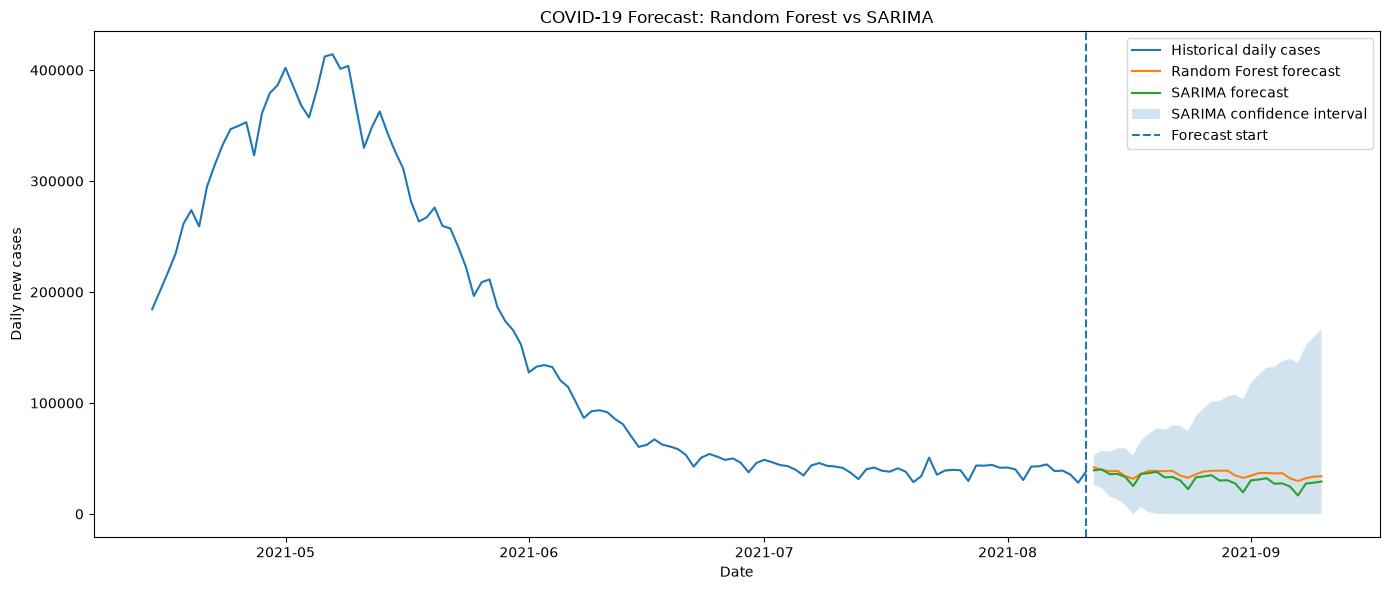

In [19]:
# 20. Forecast visualization

plt.figure(figsize=(14, 6))

history_plot = national.tail(120)

plt.plot(
    history_plot["Date"],
    history_plot["NewCases"],
    label="Historical daily cases"
)

plt.plot(
    rf_future_df["Date"],
    rf_future_df["Predicted"],
    label="Random Forest forecast"
)

plt.plot(
    sarima_future_df["Date"],
    sarima_future_df["Predicted"],
    label="SARIMA forecast"
)

plt.fill_between(
    sarima_future_df["Date"],
    sarima_future_df["Lower_Bound"],
    sarima_future_df["Upper_Bound"],
    alpha=0.2,
    label="SARIMA confidence interval"
)

plt.axvline(
    national["Date"].max(),
    linestyle="--",
    label="Forecast start"
)

plt.xlabel("Date")
plt.ylabel("Daily new cases")
plt.title("COVID-19 Forecast: Random Forest vs SARIMA")
plt.legend()
plt.tight_layout()
plt.show()


## 21. Final reporting notes

For the final report:

- Report both **holdout** and **rolling-origin** metrics.
- Use RMSE/MAE to compare predictive performance.
- Explain that SARIMA explicitly models temporal structure and weekly seasonality.
- Explain that Random Forest captures nonlinear relationships from lag/rolling features.
- Do not claim that the selected model is universally superior; it is superior only under the validation setup used here.
- Treat the 30-day forecast as a historical forecasting experiment because the underlying dataset ends in 2021.
- Do not interpret the forecast as a prediction of present-day COVID conditions.
